<a href="https://colab.research.google.com/github/Emmanuel-Yerbo/GIS/blob/main/Python%20for%20Urban%20Analysis/Chapter-6/Chap6_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 — A Simple Livability Index: Scoring All 29 Districts
## Python for Urban Analysis — Ghana Edition



### Learning Objectives
1. Scale the pipeline across multiple districts (Greater Accra's 29 MMDAs)
2. Compute per-district indicators from OSM data
3. Normalise and combine indicators into a composite livability score
4. Produce a choropleth ranking map and summary table

### Methodology
- **Amenity density**: POIs per km²
- **Road network density**: Total road km per km²
- **Building density**: Footprint count per km²
- **Green space ratio**: leisure area / district area × 100

**Min-Max Normalisation** wraps each indicator to a $[0, 1]$ scale. We then average them equally to get the final composite score.

## 6.0 — Install & Configure

In [1]:
!pip install -q osmnx geopandas contextily matplotlib mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx
import json
import time
from pathlib import Path

# ── Configuration ─────────────────────────────────────────────
STUDY_REGION     = 'Greater Accra Region, Ghana'
CRS_WEB_MERCATOR = 'EPSG:3857'
CRS_UTM_ACCRA    = 'EPSG:32630'
DARK_BG          = '#0e1117'

DATA_DIR    = Path('data')
OUTPUT_DIR  = Path('outputs')
FIGURES_DIR = OUTPUT_DIR / 'figures'
for d in [DATA_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Tag definitions ───────────────────────────────────────────
AMENITY_TAGS = {
    'amenity': [
        'hospital', 'clinic', 'pharmacy',
        'school', 'university', 'library',
        'marketplace', 'bank', 'atm',
        'police', 'fire_station',
        'place_of_worship', 'restaurant', 'fuel',
    ]
}
BUILDING_TAGS = {'building': True}
LEISURE_TAGS = {
    'leisure': ['park', 'playground', 'sports_centre', 'garden', 'stadium']
}

# ── The 29 districts of Greater Accra ──────────────────────────
GREATER_ACCRA_DISTRICTS = [
    'Accra Metropolitan District, Greater Accra, Ghana',
    'Tema Metropolitan District, Greater Accra, Ghana',
    'Ablekuma Central Municipal District, Greater Accra, Ghana',
    'Ablekuma North Municipal District, Greater Accra, Ghana',
    'Ablekuma West Municipal District, Greater Accra, Ghana',
    'Adenta Municipal District, Greater Accra, Ghana',
    'Ashaiman Municipal District, Greater Accra, Ghana',
    'Ayawaso Central Municipal District, Greater Accra, Ghana',
    'Ayawaso East Municipal District, Greater Accra, Ghana',
    'Ayawaso North Municipal District, Greater Accra, Ghana',
    'Ayawaso West Municipal District, Greater Accra, Ghana',
    'Ga South Municipal District, Greater Accra, Ghana',
    'Ga Central Municipal District, Greater Accra, Ghana',
    'Ga East Municipal District, Greater Accra, Ghana',
    'Ga North Municipal District, Greater Accra, Ghana',
    'Ga West Municipal District, Greater Accra, Ghana',
    'Korle Klottey Municipal District, Greater Accra, Ghana',
    'Kpone Katamanso Municipal District, Greater Accra, Ghana',
    'Krowor Municipal District, Greater Accra, Ghana',
    'La Dade-Kotopon Municipal District, Greater Accra, Ghana',
    'La-Nkwantanang-Madina Municipal District, Greater Accra, Ghana',
    'Ledzokuku Municipal District, Greater Accra, Ghana',
    'Okaikwei North Municipal District, Greater Accra, Ghana',
    'Tema West Municipal District, Greater Accra, Ghana',
    'Weija-Gbawe Municipal District, Greater Accra, Ghana',
    'Ada East District, Greater Accra, Ghana',
    'Ada West District, Greater Accra, Ghana',
    'Ningo-Prampram District, Greater Accra, Ghana',
    'Shai-Osudoku District, Greater Accra, Ghana',
]

## 6.1 — Define Indicator Calculation Routine

For a given district, we query the boundary and features within it.

In [3]:
def compute_district_indicators(district_name):
    res = {
        'district': district_name,
        'amenity_count': 0,
        'building_count': 0,
        'road_km': 0.0,
        'green_area_m2': 0.0,
        'district_area_km2': 0.0,
        'status': 'ok',
    }
    try:
        # 1. Boundary
        gdf = ox.geocode_to_gdf(district_name)
        area_m2 = gdf.to_crs(CRS_UTM_ACCRA).area.iloc[0]
        res['district_area_km2'] = area_m2 / 1e6

        # 2. Amenities
        try:
            am = ox.features_from_place(district_name, tags=AMENITY_TAGS)
            res['amenity_count'] = len(am)
        except Exception:
            pass

        # 3. Buildings
        try:
            bl = ox.features_from_place(district_name, tags=BUILDING_TAGS)
            bl_poly = bl[bl.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
            res['building_count'] = len(bl_poly)
        except Exception:
            pass

        # 4. Roads
        try:
            G = ox.graph_from_place(district_name, network_type='drive')
            edges = ox.graph_to_gdfs(G, nodes=False)
            res['road_km'] = edges['length'].sum() / 1000.0
        except Exception:
            pass

        # 5. Green Space
        try:
            ls = ox.features_from_place(district_name, tags=LEISURE_TAGS)
            ls_poly = ls[ls.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
            if len(ls_poly) > 0:
                res['green_area_m2'] = ls_poly.to_crs(CRS_UTM_ACCRA).area.sum()
        except Exception:
            pass
    except Exception as e:
        res['status'] = f'error: {e}'
    return res

## 6.2 — Process Districts (With Caching)

Querying OSM for all 29 districts can take **15–30 minutes**. We store results in a local JSON cache file so that if your execution is interrupted, you can resume without losing progress.

In [4]:
cache_path = DATA_DIR / 'district_indicators_cache.json'
all_results = []
if cache_path.exists():
    print('Loading cached results ...')
    with open(cache_path, 'r') as f:
        all_results = json.load(f)

cached_names = {r['district'] for r in all_results}
remaining = [d for d in GREATER_ACCRA_DISTRICTS if d not in cached_names]

if remaining:
    print(f'Fetching {len(remaining)} remaining districts ...')
    for i, dname in enumerate(remaining, 1):
        short = dname.split(',')[0]
        print(f'   [{i}/{len(remaining)}] {short} ... ', end='', flush=True)
        t0 = time.time()
        res = compute_district_indicators(dname)
        print(f'({time.time()-t0:.0f}s) — {res["status"]}')
        all_results.append(res)
        # Save cache every step
        with open(cache_path, 'w') as f:
            json.dump(all_results, f, indent=2)
else:
    print('All districts loaded from cache.')

🔄 Fetching 29 remaining districts ...
   [1/29] Accra Metropolitan District ... (100s) — ok
   [2/29] Tema Metropolitan District ... (190s) — ok
   [3/29] Ablekuma Central Municipal District ... (135s) — ok
   [4/29] Ablekuma North Municipal District ... (125s) — ok
   [5/29] Ablekuma West Municipal District ... (315s) — ok
   [6/29] Adenta Municipal District ... (245s) — ok
   [7/29] Ashaiman Municipal District ... (379s) — ok
   [8/29] Ayawaso Central Municipal District ... (276s) — ok
   [9/29] Ayawaso East Municipal District ... (247s) — ok
   [10/29] Ayawaso North Municipal District ... (245s) — ok
   [11/29] Ayawaso West Municipal District ... (170s) — ok
   [12/29] Ga South Municipal District ... (245s) — ok
   [13/29] Ga Central Municipal District ... (188s) — ok
   [14/29] Ga East Municipal District ... (214s) — ok
   [15/29] Ga North Municipal District ... (244s) — ok
   [16/29] Ga West Municipal District ... (227s) — ok
   [17/29] Korle Klottey Municipal District ... (191s) 

## 6.3 — Calculate Density Indicators

In [5]:
df = pd.DataFrame(all_results)
df['short_name'] = df['district'].apply(lambda x: x.split(',')[0])

# Calculate densities per sq-km
df['amenity_density']  = df['amenity_count']  / df['district_area_km2']
df['building_density'] = df['building_count'] / df['district_area_km2']
df['road_density']     = df['road_km']        / df['district_area_km2']
df['green_ratio']      = (df['green_area_m2'] / (df['district_area_km2'] * 1e6)) * 100

df = df.replace([np.inf, -np.inf], 0).fillna(0)

## 6.4 — Normalise Scores (Min-Max)

In [6]:
indicators = ['amenity_density', 'building_density', 'road_density', 'green_ratio']
for col in indicators:
    mn, mx = df[col].min(), df[col].max()
    if mx > mn:
        df[f'{col}_norm'] = (df[col] - mn) / (mx - mn)
    else:
        df[f'{col}_norm'] = 0.0

## 6.5 — Calculate Composite Livability Score

In [7]:
norm_cols = [f'{c}_norm' for c in indicators]
df['livability_score'] = df[norm_cols].mean(axis=1)
df['livability_rank']  = df['livability_score'].rank(ascending=False).astype(int)

df = df.sort_values('livability_rank')
df[['livability_rank', 'short_name', 'livability_score'] + norm_cols].head(10)

,livability_rank,short_name,livability_score,amenity_density_norm,building_density_norm,road_density_norm,green_ratio_norm
0,1,Accra Metropolitan District,0.931247,1.000000,1.000000,0.724987,1.000000
2,2,Ablekuma Central Municipal District,0.642191,0.705598,0.746407,1.000000,0.116759
3,3,Ablekuma North Municipal District,0.594520,0.692729,0.618924,0.980030,0.086396
1,4,Tema Metropolitan District,0.483373,0.399597,0.483547,0.540349,0.510000
13,5,Ga East Municipal District,0.229986,0.000000,0.000000,0.919945,0.000000
7,6,Ayawaso Central Municipal District,0.227675,0.000000,0.910702,0.000000,0.000000
10,7,Ayawaso West Municipal District,0.215256,0.000000,0.249837,0.611188,0.000000
21,8,Ledzokuku Municipal District,0.191066,0.000000,0.000000,0.764265,0.000000
16,9,Korle Klottey Municipal District,0.177186,0.000000,0.000000,0.708742,0.000000
18,10,Krowor Municipal District,0.137112,0.000000,0.548447,0.000000,0.000000


In [8]:
df.to_csv(OUTPUT_DIR / 'livability_index.csv', index=False)
print('💾 Saved index results to outputs/livability_index.csv')

💾 Saved index results to outputs/livability_index.csv


## 6.6 — Map the District Livability Index

We download all district boundary shapes, merge the calculated livability scores, and display them as a choropleth map.

🎨 Compiling district map ...


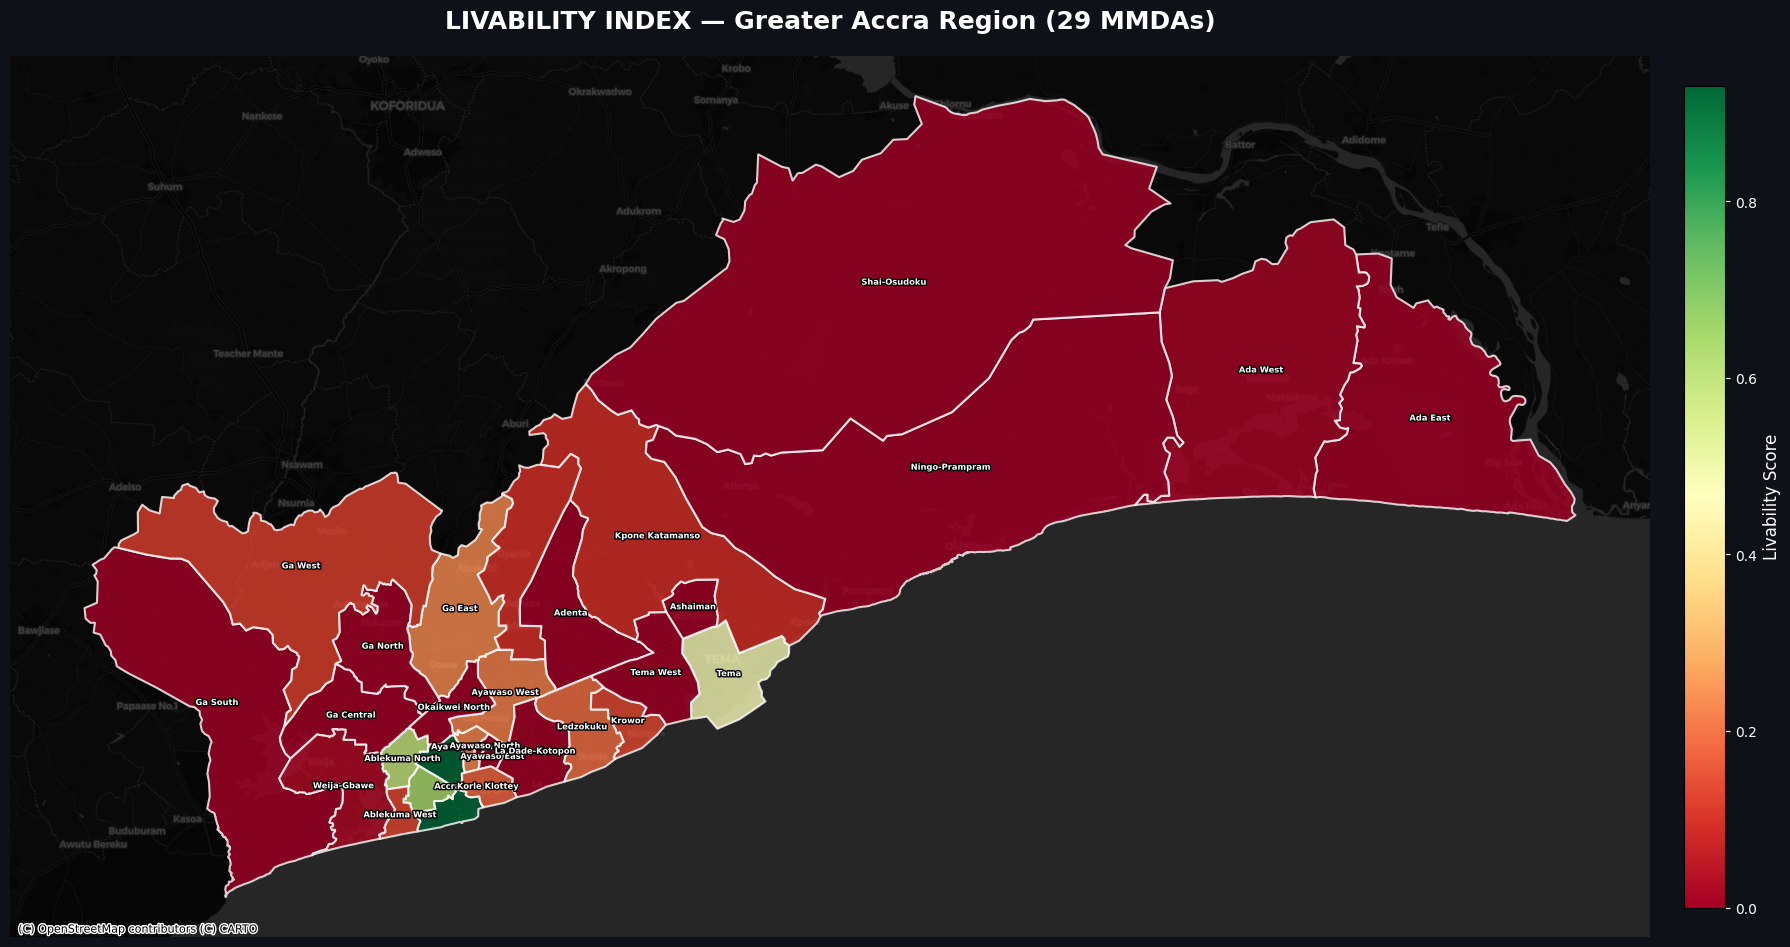

In [9]:
print('🎨 Compiling district map ...')
district_gdfs = []
for dname in GREATER_ACCRA_DISTRICTS:
    try:
        gdf = ox.geocode_to_gdf(dname)
        gdf['district'] = dname
        district_gdfs.append(gdf)
    except Exception:
        pass

if district_gdfs:
    districts_gdf = pd.concat(district_gdfs, ignore_index=True)
    districts_gdf = districts_gdf.merge(
        df[['district', 'livability_score', 'livability_rank', 'short_name']],
        on='district', how='left'
    )

    fig, ax = plt.subplots(1, 1, figsize=(18, 14))
    fig.patch.set_facecolor(DARK_BG)
    ax.set_facecolor(DARK_BG)

    districts_gdf.to_crs(CRS_WEB_MERCATOR).plot(
        ax=ax, column='livability_score', cmap='RdYlGn',
        edgecolor='white', linewidth=1.5, alpha=0.8
    )

    # Label districts
    for _, row in districts_gdf.to_crs(CRS_WEB_MERCATOR).iterrows():
        centroid = row.geometry.centroid
        label = row.get('short_name', '')
        if label and len(label) < 35:
            short = label.replace(' Municipal District', '').replace(' Metropolitan District', '').replace(' District', '')
            ax.annotate(
                short, xy=(centroid.x, centroid.y),
                fontsize=6, color='white', ha='center', va='center', fontweight='bold',
                path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=2, foreground='black')]
            )

    cx.add_basemap(ax, source=cx.providers.CartoDB.DarkMatter, zoom=11)
    ax.set_axis_off()
    ax.set_title('LIVABILITY INDEX — Greater Accra Region (29 MMDAs)', fontsize=18, fontweight='bold', color='white', pad=20)

    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=mcolors.Normalize(vmin=districts_gdf['livability_score'].min(), vmax=districts_gdf['livability_score'].max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.6)
    cbar.set_label('Livability Score', color='white', fontsize=12)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'ch6_livability_index.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
else:
    print('⚠ Could not retrieve district boundaries for plotting.')

## ✅ Course Complete!

Congratulations, you have completed the entire course curriculum!

### Summary of what you built:
1. Set up the study area pattern on OpenStreetMap.
2. Acquired spatial layers (Admin shapes, POIs, leisure landmarks).
3. Designed building density maps and footprint charts.
4. Modeled drivable vs walkable network centrality graphs.
5. Combined everything into an integrated urban profile dashboard.
6. Built a fully functional urban index pipeline running across 29 sub-districts.